# MEVO Exploratory Data Analysis

Data Quality was verified in `01_data_quality_and_baseline.ipynb`. This notebook explores how the MEVO station system behaves across time, stations, and geography. The analysis is descriptive and exploratory: it stops before Feature Engineering, target construction, Machine Learning, weather enrichment, and writing CURATED or FEATURES data.

Athena performs scans, joins, and aggregations. Pandas receives only compact hour-level, day-level, station-level, and other analysis-sized results. The notebook always discovers the available analysis period from the current CLEANED dataset.

## Imports and configuration

In [1]:
from datetime import timedelta
from zoneinfo import ZoneInfo

try:
    import boto3
    import awswrangler as wr
except ImportError as exc:
    raise ImportError(
        'This notebook requires boto3 and awswrangler. Install the project runtime dependencies before Run All.'
    ) from exc

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from botocore.exceptions import BotoCoreError, ClientError, NoCredentialsError, PartialCredentialsError
from IPython.display import display

try:
    import geopandas as gpd
    GEO_IMPORT_ERROR = None
except ImportError as exc:
    gpd = None
    GEO_IMPORT_ERROR = exc

try:
    import contextily as ctx
    CONTEXTILY_IMPORT_ERROR = None
except ImportError as exc:
    ctx = None
    CONTEXTILY_IMPORT_ERROR = exc

AWS_REGION = 'eu-north-1'
ATHENA_DATABASE = 'mevo_analytics'
ATHENA_WORKGROUP = None
ATHENA_QUERY_RESULTS = None
LOCAL_TIMEZONE = 'Europe/Warsaw'
NEAR_LIMIT_RATIO = 0.10
FACT_TABLE = f'{ATHENA_DATABASE}.fact_station_status'
DIM_TABLE = f'{ATHENA_DATABASE}.dim_station'

session = boto3.Session(region_name=AWS_REGION)
LOCAL_ZONE = ZoneInfo(LOCAL_TIMEZONE)

The project dependency declarations currently include `boto3`, `pyarrow`, and `tzdata`. They do not currently declare `awswrangler`, `pandas`, `numpy`, `matplotlib`, `geopandas`, or `contextily`. This notebook does not modify `pyproject.toml`; install the missing local packages before running all cells. GeoPandas is required for the station maps, while Contextily is optional and only adds basemap tiles.

## Read-only Athena helper

In [2]:
def run_athena_query(sql):
    '''Run a read-only Athena query and return its compact result as a DataFrame.'''
    query_kwargs = {
        'database': ATHENA_DATABASE,
        'boto3_session': session,
        'ctas_approach': False,
    }
    if ATHENA_WORKGROUP is not None:
        query_kwargs['workgroup'] = ATHENA_WORKGROUP
    if ATHENA_QUERY_RESULTS is not None:
        query_kwargs['s3_output'] = ATHENA_QUERY_RESULTS
    try:
        return wr.athena.read_sql_query(sql, **query_kwargs)
    except (NoCredentialsError, PartialCredentialsError) as exc:
        raise RuntimeError('AWS credentials are unavailable. Start the local AWS session and restart the kernel.') from exc
    except (ClientError, BotoCoreError) as exc:
        raise RuntimeError('Athena query failed. Check the local AWS session, Glue permissions, and workgroup output configuration.') from exc

## Analysis period

In [3]:
period_summary = run_athena_query(f'''
    SELECT
        COUNT(*) AS row_count,
        MIN(snapshot_ts) AS first_snapshot,
        MAX(snapshot_ts) AS last_snapshot,
        COUNT(DISTINCT snapshot_ts) AS snapshot_count,
        COUNT(DISTINCT station_id) AS station_count
    FROM {FACT_TABLE}
''')

if period_summary.empty or pd.isna(period_summary.loc[0, 'first_snapshot']):
    raise RuntimeError('The CLEANED fact_station_status table contains no observations.')

first_snapshot = pd.to_datetime(period_summary.loc[0, 'first_snapshot'], utc=True)
last_snapshot = pd.to_datetime(period_summary.loc[0, 'last_snapshot'], utc=True)
period_summary['row_count'] = pd.to_numeric(period_summary['row_count'])
period_summary['snapshot_count'] = pd.to_numeric(period_summary['snapshot_count'])
period_summary['station_count'] = pd.to_numeric(period_summary['station_count'])
duration = last_snapshot - first_snapshot

analysis_period = pd.DataFrame([{
    'first snapshot (UTC)': first_snapshot,
    'last snapshot (UTC)': last_snapshot,
    'duration': duration,
    'row count': int(period_summary.loc[0, 'row_count']),
    'snapshot count': int(period_summary.loc[0, 'snapshot_count']),
    'station count': int(period_summary.loc[0, 'station_count']),
}])
display(analysis_period)

def athena_timestamp_literal(timestamp):
    timestamp = pd.Timestamp(timestamp).tz_convert('UTC')
    return f"TIMESTAMP '{timestamp.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}'"

FACT_PERIOD_FILTER = (
    f"f.snapshot_ts >= {athena_timestamp_literal(first_snapshot)} "
    f"AND f.snapshot_ts <= {athena_timestamp_literal(last_snapshot)}"
)

# CLEANED timestamps are stored as UTC timestamps. This expression converts them
# to Europe/Warsaw before extracting local calendar fields.
LOCAL_TS = "at_timezone(with_timezone(f.snapshot_ts, 'UTC'), 'Europe/Warsaw')"
print(f'Analysis period: {first_snapshot.isoformat()} to {last_snapshot.isoformat()}')

,first snapshot (UTC),last snapshot (UTC),duration,row count,snapshot count,station count
0,2026-08-12 00:52:12.353000+00:00,2026-08-20 21:58:08.344000+00:00,8 days 21:05:55.991000,1074568,1277,847


Analysis period: 2026-08-12T00:52:12.353000+00:00 to 2026-08-20T21:58:08.344000+00:00


## Temporal EDA

All hour-of-day, day-of-week, and weekday/weekend fields below are derived after converting the UTC `snapshot_ts` to `Europe/Warsaw`. The figures show observed station state and availability; they are not demand, pickup, return, ride, or trip measures.

Hour-of-day patterns describe station availability. They should not be interpreted as direct morning/evening demand peaks; flow-oriented peak analysis will be performed later using net station changes.

In [4]:
hourly_system = run_athena_query(f'''
    SELECT
        date_trunc('hour', f.snapshot_ts) AS snapshot_hour_utc,
        AVG(CAST(f.bikes_available AS DOUBLE)) AS avg_bikes_available,
        AVG(CAST(f.classic_bikes_available AS DOUBLE)) AS avg_classic_bikes_available,
        AVG(CAST(f.ebikes_available AS DOUBLE)) AS avg_ebikes_available,
        AVG(CAST(f.docks_available AS DOUBLE)) AS avg_docks_available,
        COUNT(DISTINCT f.station_id) AS reporting_station_count
    FROM {FACT_TABLE} f
    WHERE {FACT_PERIOD_FILTER}
    GROUP BY 1
    ORDER BY 1
''')
hourly_system['snapshot_hour_utc'] = pd.to_datetime(
    hourly_system['snapshot_hour_utc'],
    utc=True,
)
hourly_system['local_hour'] = (
    hourly_system['snapshot_hour_utc'].dt.tz_convert(LOCAL_TIMEZONE)
)
for column in hourly_system.columns:
    if column not in ('snapshot_hour_utc', 'local_hour'):
        hourly_system[column] = pd.to_numeric(hourly_system[column], errors='coerce')
display(hourly_system.head())
print(f'Compact hourly result: {len(hourly_system):,} rows')

,snapshot_hour_utc,avg_bikes_available,avg_classic_bikes_available,avg_ebikes_available,avg_docks_available,reporting_station_count,local_hour
0,2026-08-12 00:00:00+00:00,4.654719,1.211470,3.443250,7.169654,837,2026-08-12 02:00:00+02:00
1,2026-08-12 01:00:00+00:00,4.713978,1.217682,3.496296,7.130466,837,2026-08-12 03:00:00+02:00
2,2026-08-12 02:00:00+00:00,4.725806,1.217244,3.508562,7.121266,837,2026-08-12 04:00:00+02:00
3,2026-08-12 03:00:00+00:00,4.576663,1.208284,3.368379,7.165273,837,2026-08-12 05:00:00+02:00
4,2026-08-12 04:00:00+00:00,4.457985,1.200319,3.257666,7.254281,837,2026-08-12 06:00:00+02:00


Compact hourly result: 214 rows


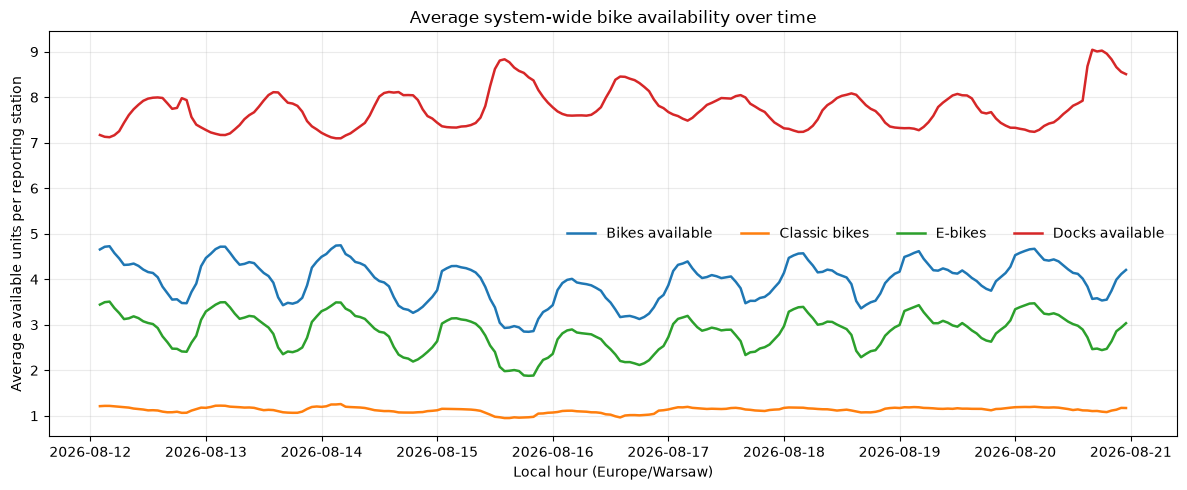

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for column, label in [
    ('avg_bikes_available', 'Bikes available'),
    ('avg_classic_bikes_available', 'Classic bikes'),
    ('avg_ebikes_available', 'E-bikes'),
    ('avg_docks_available', 'Docks available'),
]:
    ax.plot(hourly_system['local_hour'], hourly_system[column], label=label, linewidth=1.8)
ax.set_title('Average system-wide bike availability over time')
ax.set_xlabel('Local hour (Europe/Warsaw)')
ax.set_ylabel('Average available units per reporting station')
ax.legend(ncol=4, frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

,hour_of_day,avg_bikes_available,avg_classic_bikes_available,avg_ebikes_available,avg_docks_available
0,0,4.107323,1.154486,2.952837,7.420034
1,1,4.347222,1.170727,3.176495,7.374059
2,2,4.438939,1.184918,3.254020,7.340949
3,3,4.506337,1.188101,3.318236,7.298809
4,4,4.526137,1.190272,3.335866,7.284252
5,5,4.395605,1.172546,3.223059,7.328269
6,6,4.300568,1.166557,3.134012,7.395341
7,7,4.210926,1.160457,3.050469,7.483177
8,8,4.206985,1.153014,3.053970,7.590369
9,9,4.200167,1.147258,3.052910,7.680692


Lowest average bike availability: 18:00
Highest average bike availability: 04:00


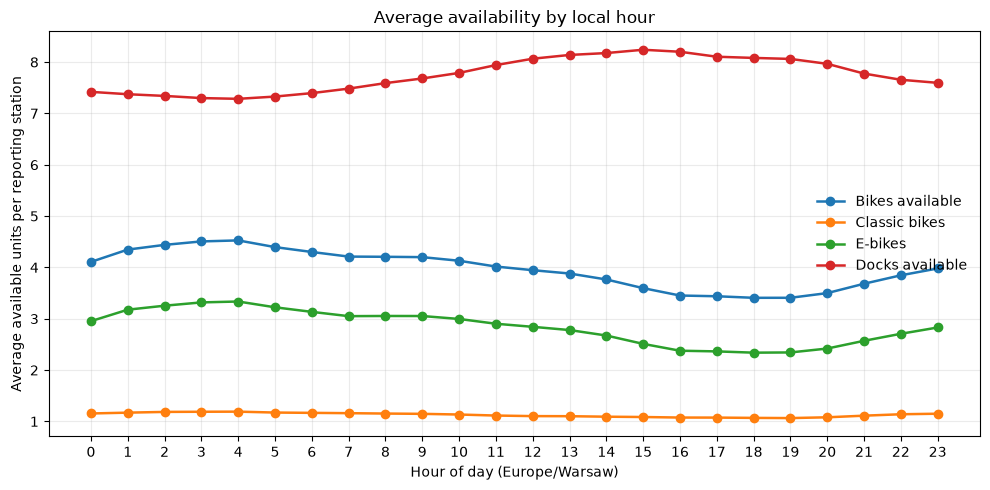

In [6]:
hour_profile = run_athena_query(f'''
    SELECT
        hour({LOCAL_TS}) AS hour_of_day,
        AVG(CAST(f.bikes_available AS DOUBLE)) AS avg_bikes_available,
        AVG(CAST(f.classic_bikes_available AS DOUBLE)) AS avg_classic_bikes_available,
        AVG(CAST(f.ebikes_available AS DOUBLE)) AS avg_ebikes_available,
        AVG(CAST(f.docks_available AS DOUBLE)) AS avg_docks_available
    FROM {FACT_TABLE} f
    WHERE {FACT_PERIOD_FILTER}
    GROUP BY 1
    ORDER BY 1
''')
hour_profile['hour_of_day'] = pd.to_numeric(hour_profile['hour_of_day']).astype(int)
numeric_columns = [column for column in hour_profile.columns if column != 'hour_of_day']
hour_profile[numeric_columns] = hour_profile[numeric_columns].apply(pd.to_numeric, errors='coerce')
lowest_hour = int(hour_profile.loc[hour_profile['avg_bikes_available'].idxmin(), 'hour_of_day'])
highest_hour = int(hour_profile.loc[hour_profile['avg_bikes_available'].idxmax(), 'hour_of_day'])
display(hour_profile)
print(f'Lowest average bike availability: {lowest_hour:02d}:00')
print(f'Highest average bike availability: {highest_hour:02d}:00')

fig, ax = plt.subplots(figsize=(10, 5))
for column, label in [
    ('avg_bikes_available', 'Bikes available'),
    ('avg_classic_bikes_available', 'Classic bikes'),
    ('avg_ebikes_available', 'E-bikes'),
    ('avg_docks_available', 'Docks available'),
]:
    ax.plot(hour_profile['hour_of_day'], hour_profile[column], marker='o', linewidth=1.8, label=label)
ax.set_title('Average availability by local hour')
ax.set_xlabel('Hour of day (Europe/Warsaw)')
ax.set_ylabel('Average available units per reporting station')
ax.set_xticks(range(24))
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

,weekday,avg_bikes_available,avg_ebikes_available,avg_docks_available,unique_calendar_dates
0,Monday,3.947404,2.795608,7.745455,1
1,Tuesday,4.038716,2.901540,7.629438,1
2,Wednesday,4.137145,2.985846,7.643193,2
3,Thursday,4.159393,3.005973,7.787476,2
4,Friday,4.001575,2.858255,7.621230,1
5,Saturday,3.564903,2.510018,7.983875,1
6,Sunday,3.567347,2.510573,7.937702,1


Preliminary weekday results: only one observed calendar date for ['Monday', 'Tuesday', 'Friday', 'Saturday', 'Sunday'].


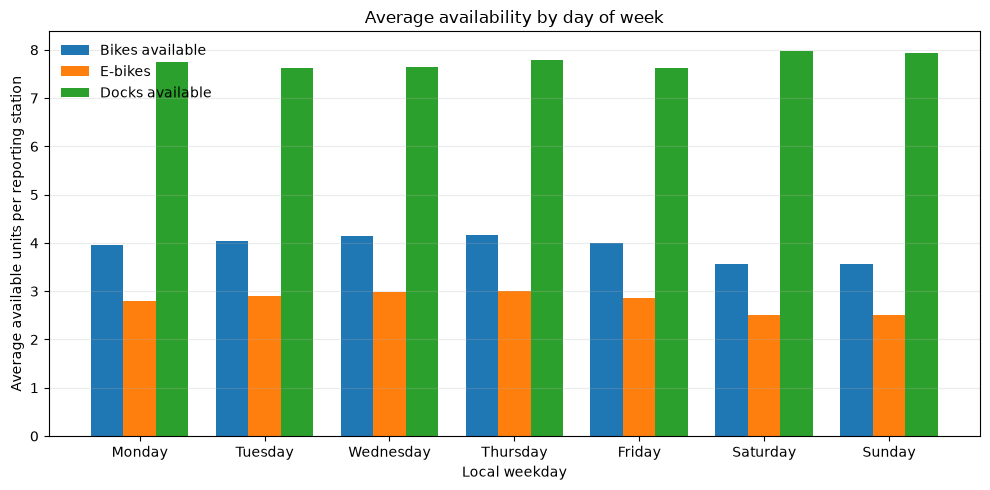

In [7]:
weekday_profile = run_athena_query(f'''
    SELECT
        day_of_week({LOCAL_TS}) AS weekday_number,
        AVG(CAST(f.bikes_available AS DOUBLE)) AS avg_bikes_available,
        AVG(CAST(f.ebikes_available AS DOUBLE)) AS avg_ebikes_available,
        AVG(CAST(f.docks_available AS DOUBLE)) AS avg_docks_available,
        COUNT(DISTINCT date({LOCAL_TS})) AS unique_calendar_dates
    FROM {FACT_TABLE} f
    WHERE {FACT_PERIOD_FILTER}
    GROUP BY 1
    ORDER BY 1
''')
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_profile['weekday_number'] = pd.to_numeric(weekday_profile['weekday_number']).astype(int)
weekday_profile['weekday'] = weekday_profile['weekday_number'].map(dict(enumerate(weekday_names, start=1)))
weekday_profile['weekday'] = pd.Categorical(weekday_profile['weekday'], categories=weekday_names, ordered=True)
weekday_profile = weekday_profile.sort_values('weekday').reset_index(drop=True)
for column in ['avg_bikes_available', 'avg_ebikes_available', 'avg_docks_available', 'unique_calendar_dates']:
    weekday_profile[column] = pd.to_numeric(weekday_profile[column], errors='coerce')
display(weekday_profile[['weekday', 'avg_bikes_available', 'avg_ebikes_available', 'avg_docks_available', 'unique_calendar_dates']])
preliminary_days = weekday_profile.loc[weekday_profile['unique_calendar_dates'] <= 1, 'weekday'].astype(str).tolist()
if preliminary_days:
    print(f'Preliminary weekday results: only one observed calendar date for {preliminary_days}.')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(weekday_profile))
width = 0.26
for offset, column, label in [
    (-width, 'avg_bikes_available', 'Bikes available'),
    (0, 'avg_ebikes_available', 'E-bikes'),
    (width, 'avg_docks_available', 'Docks available'),
]:
    ax.bar(x + offset, weekday_profile[column], width=width, label=label)
ax.set_title('Average availability by day of week')
ax.set_xlabel('Local weekday')
ax.set_ylabel('Average available units per reporting station')
ax.set_xticks(x, weekday_profile['weekday'].astype(str))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

,period_type,avg_bikes_available,avg_ebikes_available,avg_docks_available
0,Weekday,4.081956,2.933185,7.694863
1,Weekend,3.566121,2.510294,7.960863


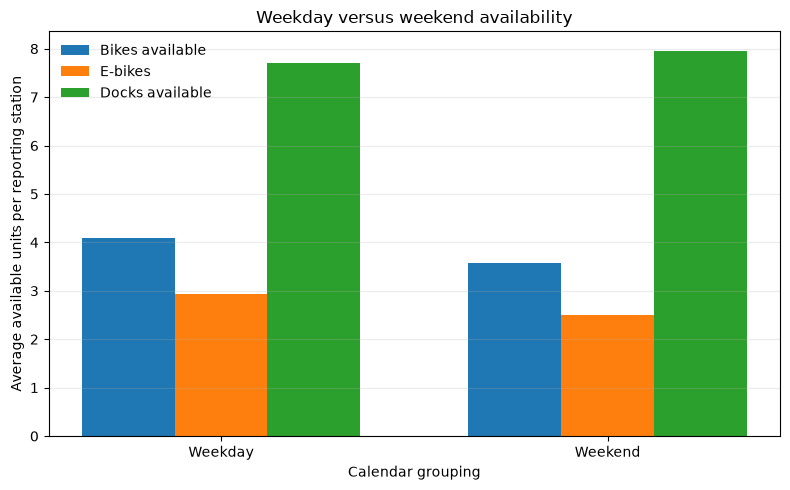

In [8]:
weekday_weekend = run_athena_query(f'''
    SELECT
        CASE WHEN day_of_week({LOCAL_TS}) <= 5 THEN 'Weekday' ELSE 'Weekend' END AS period_type,
        AVG(CAST(f.bikes_available AS DOUBLE)) AS avg_bikes_available,
        AVG(CAST(f.ebikes_available AS DOUBLE)) AS avg_ebikes_available,
        AVG(CAST(f.docks_available AS DOUBLE)) AS avg_docks_available
    FROM {FACT_TABLE} f
    WHERE {FACT_PERIOD_FILTER}
    GROUP BY 1
    ORDER BY CASE WHEN period_type = 'Weekday' THEN 1 ELSE 2 END
''')
for column in ['avg_bikes_available', 'avg_ebikes_available', 'avg_docks_available']:
    weekday_weekend[column] = pd.to_numeric(weekday_weekend[column], errors='coerce')
display(weekday_weekend)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(weekday_weekend))
width = 0.24
for offset, column, label in [
    (-width, 'avg_bikes_available', 'Bikes available'),
    (0, 'avg_ebikes_available', 'E-bikes'),
    (width, 'avg_docks_available', 'Docks available'),
]:
    ax.bar(x + offset, weekday_weekend[column], width=width, label=label)
ax.set_title('Weekday versus weekend availability')
ax.set_xlabel('Calendar grouping')
ax.set_ylabel('Average available units per reporting station')
ax.set_xticks(x, weekday_weekend['period_type'])
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## Station-level EDA

`dim_station` contains multiple reference snapshots. Every station-level and geospatial query uses `latest_station_dimension`, selecting one row per `station_id` with `ROW_NUMBER() OVER (PARTITION BY station_id ORDER BY snapshot_ts DESC)`. This avoids a naive fact-to-dimension many-to-many join. The `avg_availability_ratio` is an availability / station occupancy-state indicator, not actual user utilization.

Station-state definitions use the explicit, centrally configured `NEAR_LIMIT_RATIO = 0.10`: `empty` means `bikes_available == 0`; `nearly_empty` means positive capacity, positive available bikes, and `bikes_available / capacity <= 0.10`; `full` means `docks_available == 0`; `nearly_full` means positive capacity, positive available docks, and `docks_available / capacity <= 0.10`. The 10% threshold is an analytical rule for this notebook, not an official MEVO definition.

In [9]:
station_baseline = run_athena_query(f'''
    WITH latest_station_dimension AS (
        SELECT station_id, station_name, address, cross_street, latitude, longitude, capacity, is_virtual_station
        FROM (
            SELECT
                d.*,
                ROW_NUMBER() OVER (PARTITION BY station_id ORDER BY snapshot_ts DESC) AS rn
            FROM {DIM_TABLE} d
        )
        WHERE rn = 1
    )
    SELECT
        f.station_id,
        d.station_name,
        d.address,
        d.cross_street,
        d.latitude,
        d.longitude,
        d.capacity,
        d.is_virtual_station,
        COUNT(*) AS observation_count,
        AVG(CAST(f.bikes_available AS DOUBLE)) AS avg_bikes_available,
        approx_percentile(CAST(f.bikes_available AS DOUBLE), 0.5) AS median_bikes_available,
        AVG(CAST(f.classic_bikes_available AS DOUBLE)) AS avg_classic_bikes_available,
        AVG(CAST(f.ebikes_available AS DOUBLE)) AS avg_ebikes_available,
        AVG(CAST(f.docks_available AS DOUBLE)) AS avg_docks_available,
        AVG(CASE WHEN d.capacity > 0 THEN CAST(f.bikes_available AS DOUBLE) / CAST(d.capacity AS DOUBLE) END) AS avg_availability_ratio,
        100.0 * AVG(CASE WHEN f.bikes_available = 0 THEN 1.0 ELSE 0.0 END) AS pct_empty_snapshots,
        100.0 * AVG(CASE WHEN d.capacity > 0 AND f.bikes_available > 0 AND CAST(f.bikes_available AS DOUBLE) / CAST(d.capacity AS DOUBLE) <= {NEAR_LIMIT_RATIO} THEN 1.0 ELSE 0.0 END) AS pct_nearly_empty_snapshots,
        100.0 * AVG(CASE WHEN f.docks_available = 0 THEN 1.0 ELSE 0.0 END) AS pct_full_snapshots,
        100.0 * AVG(CASE WHEN d.capacity > 0 AND f.docks_available > 0 AND CAST(f.docks_available AS DOUBLE) / CAST(d.capacity AS DOUBLE) <= {NEAR_LIMIT_RATIO} THEN 1.0 ELSE 0.0 END) AS pct_nearly_full_snapshots,
        100.0 * SUM(CAST(f.ebikes_available AS DOUBLE)) / NULLIF(SUM(CAST(f.bikes_available AS DOUBLE)), 0) AS ebike_share
    FROM {FACT_TABLE} f
    LEFT JOIN latest_station_dimension d ON f.station_id = d.station_id
    WHERE {FACT_PERIOD_FILTER}
    GROUP BY f.station_id, d.station_name, d.address, d.cross_street, d.latitude, d.longitude, d.capacity, d.is_virtual_station
    ORDER BY avg_bikes_available DESC
''')
numeric_station_columns = [
    'latitude', 'longitude', 'capacity', 'observation_count', 'avg_bikes_available',
    'median_bikes_available', 'avg_classic_bikes_available', 'avg_ebikes_available',
    'avg_docks_available', 'avg_availability_ratio', 'pct_empty_snapshots',
    'pct_nearly_empty_snapshots', 'pct_full_snapshots', 'pct_nearly_full_snapshots',
    'ebike_share',
]
for column in numeric_station_columns:
    station_baseline[column] = pd.to_numeric(station_baseline[column], errors='coerce')
display(station_baseline.head())
print(f'Compact station-level result: {len(station_baseline):,} rows')

,station_id,station_name,address,cross_street,latitude,longitude,capacity,is_virtual_station,observation_count,avg_bikes_available,median_bikes_available,avg_classic_bikes_available,avg_ebikes_available,avg_docks_available,avg_availability_ratio,pct_empty_snapshots,pct_nearly_empty_snapshots,pct_full_snapshots,pct_nearly_full_snapshots,ebike_share
0,4352,SOP008,"Plac Zdrojowy 2, 81-720 Sopot","Plac Zdrojowy 2, 81-720 Sopot",54.445226,18.570999,10,True,1277,50.037588,41.959259,12.094753,37.942835,0.746280,5.003759,0.000000,0.861394,83.868442,1.174628,75.828664
1,3899,GDA071,"Jantarowa 21, 80-341 Gdańsk","Jantarowa 21, 80-341 Gdańsk",54.413368,18.623833,10,True,1277,25.332028,12.753517,11.342991,13.989037,1.309319,2.533203,2.270948,5.168363,70.477682,2.819107,55.222727
2,3893,GDA065,"Aleja Grunwaldzka 472, 80-309 Gdańsk","Aleja Grunwaldzka 472, 80-309 Gdańsk",54.402504,18.572629,10,True,1277,22.001566,2.212073,1.978074,20.023493,4.858262,2.200157,30.540329,13.469068,38.997651,0.313234,91.009396
3,4268,GDY077,Bulwar Nadmorski 1/40,Bulwar Nadmorski 1/40,54.516345,18.548399,10,True,1277,21.964761,19.801529,13.599843,8.364918,0.097103,2.196476,0.000000,0.078309,93.030540,4.228661,38.083354
4,4307,GDY116,Orłowska 12,Orłowska 12,54.480808,18.563843,10,True,1277,16.302271,16.721608,10.974941,5.327330,1.192639,1.630227,5.716523,1.018011,74.393109,10.493344,32.678451


Compact station-level result: 847 rows


In [10]:
station_columns = [
    'station_id', 'station_name', 'capacity', 'observation_count',
    'avg_bikes_available', 'avg_availability_ratio', 'pct_empty_snapshots',
    'pct_nearly_empty_snapshots', 'pct_full_snapshots', 'pct_nearly_full_snapshots',
    'ebike_share',
]
station_rankings = station_baseline.copy()
station_rankings['station_label'] = station_rankings['station_name'].fillna(station_rankings['station_id'])
station_rankings['station_label'] = station_rankings['station_label'].astype(str)

top_10_availability = station_rankings.nlargest(10, 'avg_bikes_available')[station_columns]
bottom_10_availability = station_rankings.nsmallest(10, 'avg_bikes_available')[station_columns]
ratio_rankings = station_rankings.dropna(subset=['avg_availability_ratio'])
top_10_ratio = ratio_rankings.nlargest(10, 'avg_availability_ratio')[station_columns]
bottom_10_ratio = ratio_rankings.nsmallest(10, 'avg_availability_ratio')[station_columns]
top_10_empty = station_rankings.nlargest(10, 'pct_empty_snapshots')[station_columns]
top_10_full = station_rankings.nlargest(10, 'pct_full_snapshots')[station_columns]
near_state_columns = [
    'station_id', 'station_name', 'capacity', 'observation_count',
    'pct_empty_snapshots', 'pct_nearly_empty_snapshots',
    'pct_full_snapshots', 'pct_nearly_full_snapshots',
]
top_10_nearly_empty = station_rankings.nlargest(10, 'pct_nearly_empty_snapshots')[near_state_columns]
top_10_nearly_full = station_rankings.nlargest(10, 'pct_nearly_full_snapshots')[near_state_columns]

print('Top 10 stations by average available bikes')
display(top_10_availability)
print('Bottom 10 stations by average available bikes')
display(bottom_10_availability)
print('Top 10 stations by average availability ratio')
display(top_10_ratio)
print('Bottom 10 stations by average availability ratio')
display(bottom_10_ratio)

print('Top 10 stations most frequently observed empty: bikes_available == 0')
display(top_10_empty)
print('Top 10 stations most frequently observed full: docks_available == 0')
display(top_10_full)
print('Top 10 stations most frequently observed nearly empty (10% threshold)')
display(top_10_nearly_empty)
print('Top 10 stations most frequently observed nearly full (10% threshold)')
display(top_10_nearly_full)

Top 10 stations by average available bikes


,station_id,station_name,capacity,observation_count,avg_bikes_available,avg_availability_ratio,pct_empty_snapshots,pct_nearly_empty_snapshots,pct_full_snapshots,pct_nearly_full_snapshots,ebike_share
0,4352,SOP008,10,1277,50.037588,5.003759,0.000000,0.861394,83.868442,1.174628,75.828664
1,3899,GDA071,10,1277,25.332028,2.533203,2.270948,5.168363,70.477682,2.819107,55.222727
2,3893,GDA065,10,1277,22.001566,2.200157,30.540329,13.469068,38.997651,0.313234,91.009396
3,4268,GDY077,10,1277,21.964761,2.196476,0.000000,0.078309,93.030540,4.228661,38.083354
4,4307,GDY116,10,1277,16.302271,1.630227,5.716523,1.018011,74.393109,10.493344,32.678451
5,3900,GDA072,10,1277,15.476899,1.547690,2.427565,6.656226,62.490211,3.837118,67.410443
6,3855,GDA027,10,1277,13.981206,1.398121,22.866092,14.252153,34.534064,0.783085,93.894926
7,4296,GDY105,10,1277,13.584965,1.358496,0.000000,0.000000,84.181676,3.680501,43.958958
8,3896,GDA068,10,1277,13.079875,1.307987,23.962412,19.263900,36.413469,0.469851,85.511585
9,4266,GDY075,10,1277,12.898199,1.289820,2.819107,2.192639,46.750196,3.367267,71.416429


Bottom 10 stations by average available bikes


,station_id,station_name,capacity,observation_count,avg_bikes_available,avg_availability_ratio,pct_empty_snapshots,pct_nearly_empty_snapshots,pct_full_snapshots,pct_nearly_full_snapshots,ebike_share
843,4524,KAR016,10,1277,0.000000,0.000000,100.000000,0.000000,0.0,0.0,NaN
844,5715,RUM024,10,1277,0.000000,0.000000,100.000000,0.000000,0.0,0.0,NaN
845,4470,PUC001,10,1277,0.000000,0.000000,100.000000,0.000000,0.0,0.0,NaN
846,7849,Hel Riders,20,1277,0.000000,0.000000,100.000000,0.000000,0.0,0.0,NaN
842,8308,GDY156,10,375,0.002667,0.000267,99.733333,0.266667,0.0,0.0,100.000000
841,4372,SOP028,10,1277,0.018011,0.001801,98.198904,1.801096,0.0,0.0,100.000000
840,4507,ZUK004,10,1277,0.021926,0.002193,97.807361,2.192639,0.0,0.0,100.000000
839,8306,GDY155,10,1075,0.142326,0.014233,85.767442,14.232558,0.0,0.0,100.000000
838,4525,SOM001,10,1277,0.170713,0.017071,82.928739,17.071261,0.0,0.0,100.000000
837,4471,PUC002,10,1277,0.174628,0.017463,85.199687,12.137823,0.0,0.0,87.892377


Top 10 stations by average availability ratio


...

,station_id,station_name,capacity,observation_count,avg_bikes_available,avg_availability_ratio,pct_empty_snapshots,pct_nearly_empty_snapshots,pct_full_snapshots,pct_nearly_full_snapshots,ebike_share
15,4526,SOM002,10,1277,11.819107,1.181911,0.000000,0.000000,100.000000,0.000000,91.539124
3,4268,GDY077,10,1277,21.964761,2.196476,0.000000,0.078309,93.030540,4.228661,38.083354
41,4295,GDY104,7,1277,9.474550,1.353507,0.000000,0.000000,88.801879,0.000000,48.045293
7,4296,GDY105,10,1277,13.584965,1.358496,0.000000,0.000000,84.181676,3.680501,43.958958
0,4352,SOP008,10,1277,50.037588,5.003759,0.000000,0.861394,83.868442,1.174628,75.828664
36,4235,GDY044,10,1277,9.663273,0.966327,0.000000,0.000000,80.579483,6.264683,48.225284
37,4503,WLA020,10,1277,9.660924,0.966092,2.819107,5.246672,77.133908,4.463587,86.163573
32,4212,GDY021,10,1277,9.896633,0.989663,0.000000,0.000000,77.055599,7.595928,70.778604
25,4219,GDY028,10,1277,10.841034,1.084103,0.000000,0.000000,76.977291,12.999217,28.308292
31,4264,GDY073,10,1277,9.924824,0.992482,0.000000,0.000000,76.350822,4.698512,36.783967


Top 10 stations most frequently observed nearly empty (10% threshold)


,station_id,station_name,capacity,observation_count,pct_empty_snapshots,pct_nearly_empty_snapshots,pct_full_snapshots,pct_nearly_full_snapshots
386,5730,GPG001,50,1277,1.409554,89.428348,0.0,0.0
778,8255,SKA002,10,1277,16.601410,78.386844,0.0,0.0
511,5735,GPG011,50,1277,14.408771,72.122161,0.0,0.0
795,4522,KAR014,10,1277,29.600626,70.399374,0.0,0.0
728,4680,OMGGS,50,1277,33.437745,64.526233,0.0,0.0
268,5731,GPG004,50,1277,3.837118,61.785435,0.0,0.0
747,4542,KOS004,10,1277,12.842600,59.827721,0.0,0.0
237,3915,GDA087,500,1277,41.581832,58.418168,0.0,0.0
762,4519,KAR011,10,1277,22.317933,56.068912,0.0,0.0
506,3886,GDA058,30,1277,16.131558,54.267815,0.0,0.0


Top 10 stations most frequently observed nearly full (10% threshold)


,station_id,station_name,capacity,observation_count,pct_empty_snapshots,pct_nearly_empty_snapshots,pct_full_snapshots,pct_nearly_full_snapshots
68,5724,GDA396,10,1277,1.409554,3.445576,35.552075,22.944401
115,8258,GTC004,10,1277,0.000000,0.000000,18.402506,20.438528
16,4332,GDY141,10,1277,0.000000,0.783085,44.949099,19.185591
159,4214,GDY023,10,1277,0.000000,2.975724,32.184808,18.167580
34,4537,KOL004,10,1277,0.000000,0.548160,65.152702,17.776038
111,4263,GDY072,10,1277,0.078309,5.481597,25.685200,16.836335
181,4258,GDY067,10,1277,2.427565,4.306969,13.625685,16.366484
218,4174,GDA346,10,1277,21.691464,21.691464,23.649178,16.288175
194,4303,GDY112,10,1277,3.523884,8.300705,40.093970,15.974941
101,4260,GDY069,10,1277,0.000000,0.000000,16.444792,15.191856


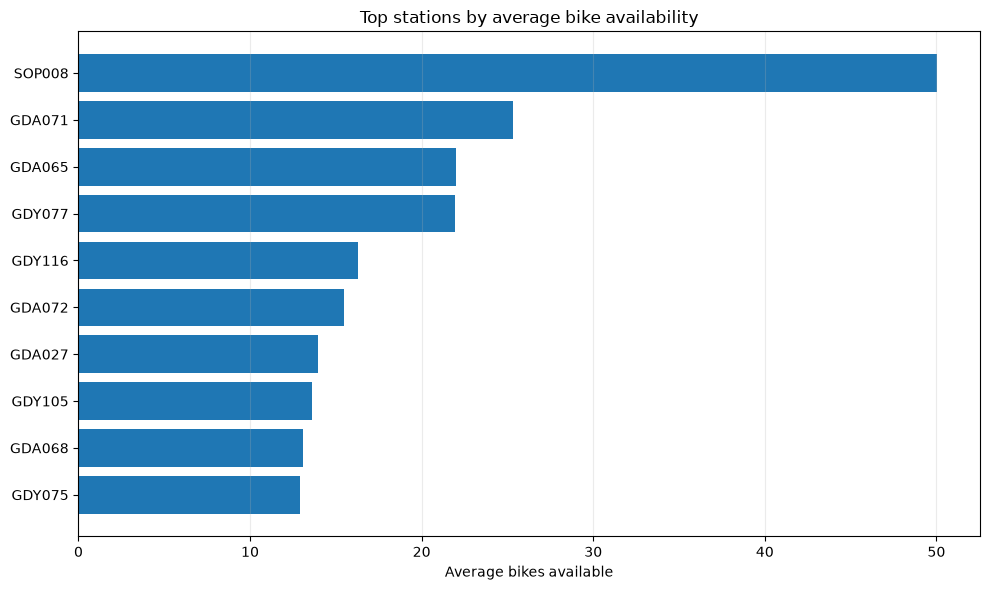

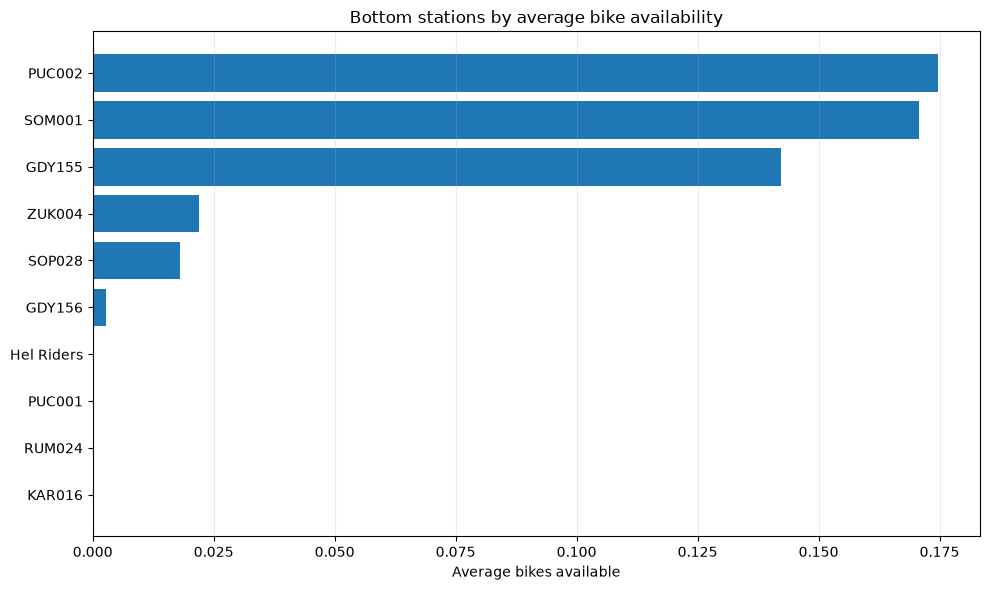

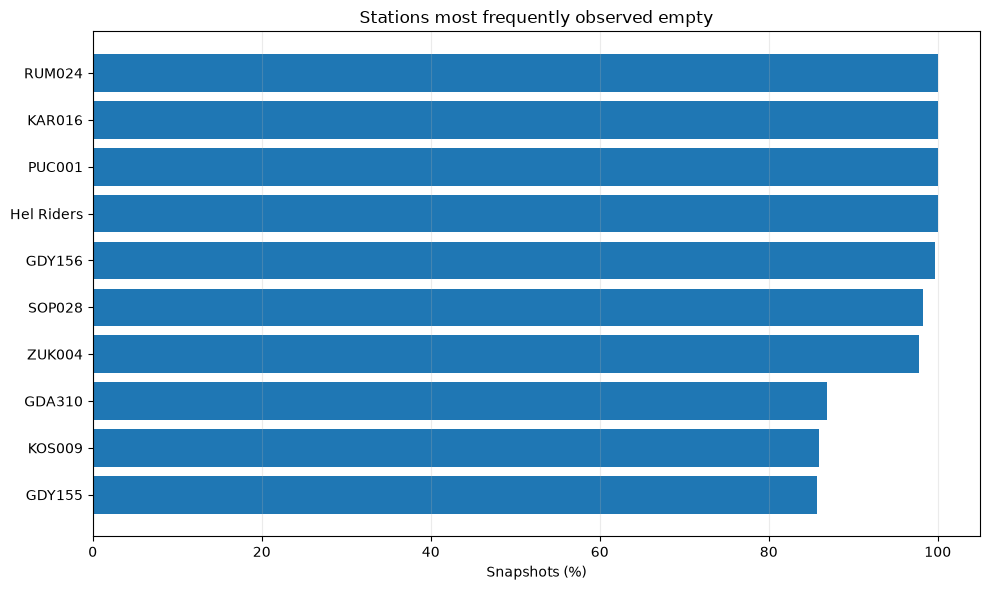

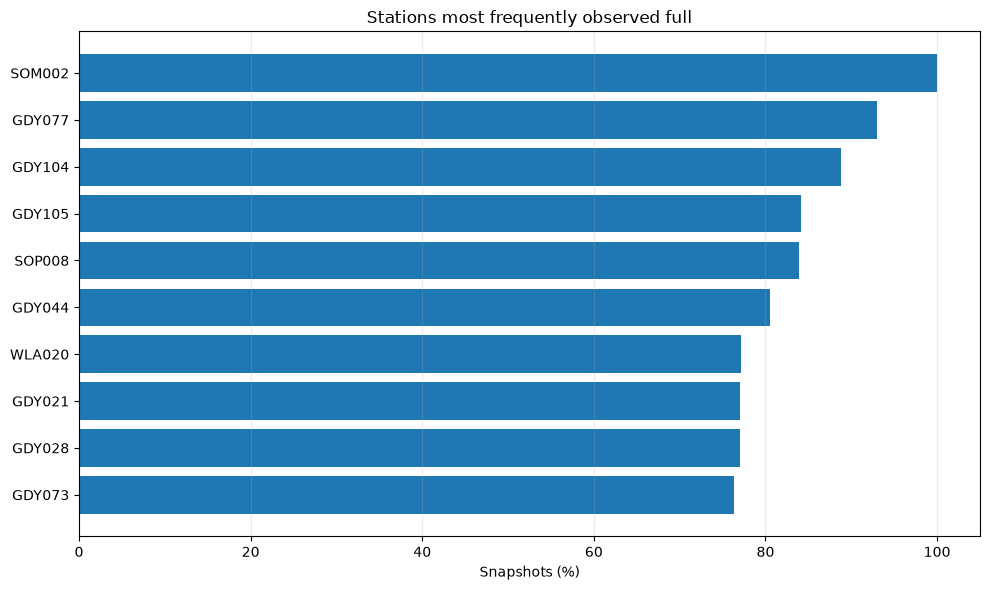

In [11]:
def station_bar_label(frame):
    return frame['station_name'].fillna(frame['station_id']).astype(str).str.slice(0, 36)

fig, ax = plt.subplots(figsize=(10, 6))
frame = top_10_availability.sort_values('avg_bikes_available')
ax.barh(station_bar_label(frame), frame['avg_bikes_available'])
ax.set_title('Top stations by average bike availability')
ax.set_xlabel('Average bikes available')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
frame = bottom_10_availability.sort_values('avg_bikes_available')
ax.barh(station_bar_label(frame), frame['avg_bikes_available'])
ax.set_title('Bottom stations by average bike availability')
ax.set_xlabel('Average bikes available')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
frame = top_10_empty.sort_values('pct_empty_snapshots')
ax.barh(station_bar_label(frame), frame['pct_empty_snapshots'])
ax.set_title('Stations most frequently observed empty')
ax.set_xlabel('Snapshots (%)')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
frame = top_10_full.sort_values('pct_full_snapshots')
ax.barh(station_bar_label(frame), frame['pct_full_snapshots'])
ax.set_title('Stations most frequently observed full')
ax.set_xlabel('Snapshots (%)')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

## E-bike versus classic composition

E-bike share is calculated only among available bikes, with a zero denominator returning a missing value. The metric describes the observed composition of available inventory; it is not a measure of trips or demand.

In [12]:
system_composition = run_athena_query(f'''
    SELECT
        AVG(CAST(f.classic_bikes_available AS DOUBLE)) AS avg_classic_bikes_available,
        AVG(CAST(f.ebikes_available AS DOUBLE)) AS avg_ebikes_available,
        100.0 * SUM(CAST(f.ebikes_available AS DOUBLE)) / NULLIF(SUM(CAST(f.bikes_available AS DOUBLE)), 0) AS ebike_share
    FROM {FACT_TABLE} f
    WHERE {FACT_PERIOD_FILTER}
''')
hourly_ebike_share = run_athena_query(f'''
    SELECT
        hour({LOCAL_TS}) AS hour_of_day,
        100.0 * SUM(CAST(f.ebikes_available AS DOUBLE)) / NULLIF(SUM(CAST(f.bikes_available AS DOUBLE)), 0) AS ebike_share
    FROM {FACT_TABLE} f
    WHERE {FACT_PERIOD_FILTER}
    GROUP BY 1
    ORDER BY 1
''')
for column in ['avg_classic_bikes_available', 'avg_ebikes_available', 'ebike_share']:
    system_composition[column] = pd.to_numeric(system_composition[column], errors='coerce')
hourly_ebike_share['hour_of_day'] = pd.to_numeric(hourly_ebike_share['hour_of_day']).astype(int)
hourly_ebike_share['ebike_share'] = pd.to_numeric(hourly_ebike_share['ebike_share'], errors='coerce')
display(system_composition)
display(hourly_ebike_share)

,avg_classic_bikes_available,avg_ebikes_available,ebike_share
0,1.127876,2.83811,71.561278


,hour_of_day,ebike_share
0,0,71.892009
1,1,73.069541
2,2,73.306268
3,3,73.634875
4,4,73.702262
5,5,73.324583
6,6,72.874361
7,7,72.441760
8,8,72.592852
9,9,72.685430


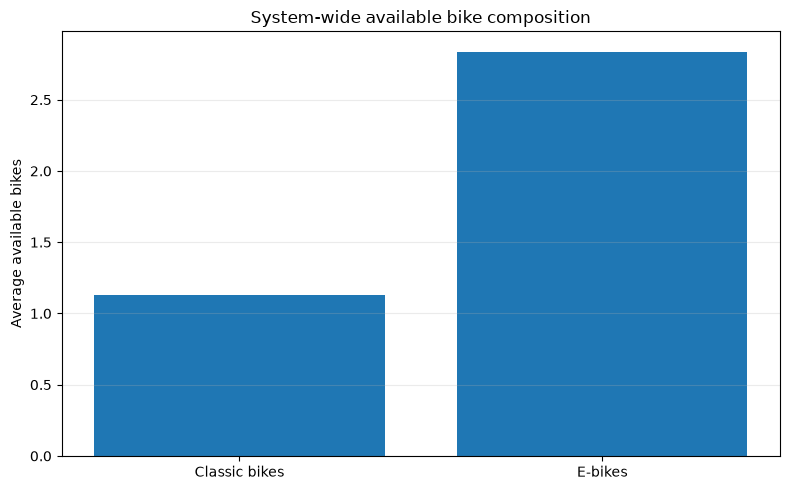

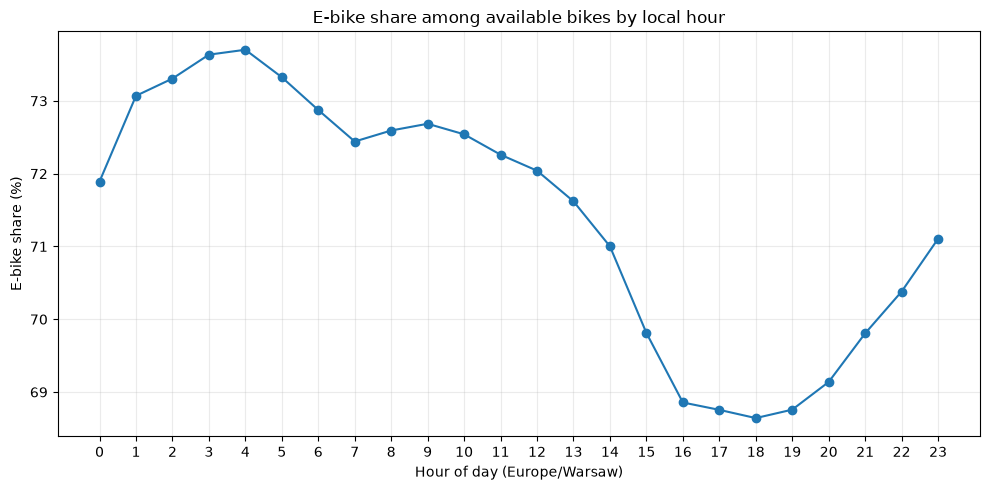

System-wide e-bike share among available bikes: 71.56%


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
composition_values = system_composition.loc[0, ['avg_classic_bikes_available', 'avg_ebikes_available']]
ax.bar(['Classic bikes', 'E-bikes'], composition_values)
ax.set_title('System-wide available bike composition')
ax.set_ylabel('Average available bikes')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_ebike_share['hour_of_day'], hourly_ebike_share['ebike_share'], marker='o')
ax.set_title('E-bike share among available bikes by local hour')
ax.set_xlabel('Hour of day (Europe/Warsaw)')
ax.set_ylabel('E-bike share (%)')
ax.set_xticks(range(24))
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
print(f"System-wide e-bike share among available bikes: {system_composition.loc[0, 'ebike_share']:.2f}%")

## Distributions and operational station flags

The distributions use the station-level aggregated dataset, not the approximately million-row fact table. Operational flags are summarized as observed snapshot counts and percentages.

The average availability ratio histogram is limited to values up to the 98th percentile for readability. Raw values remain unchanged in `station_baseline`, and the number of stations above p98 is reported on the figure.

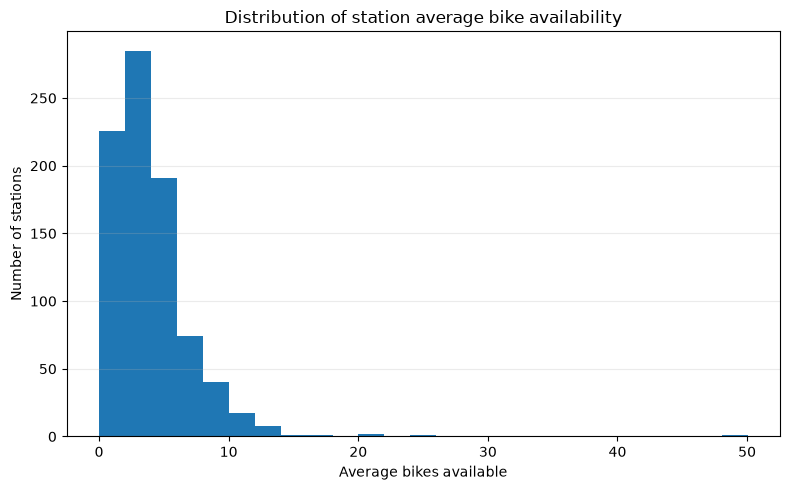

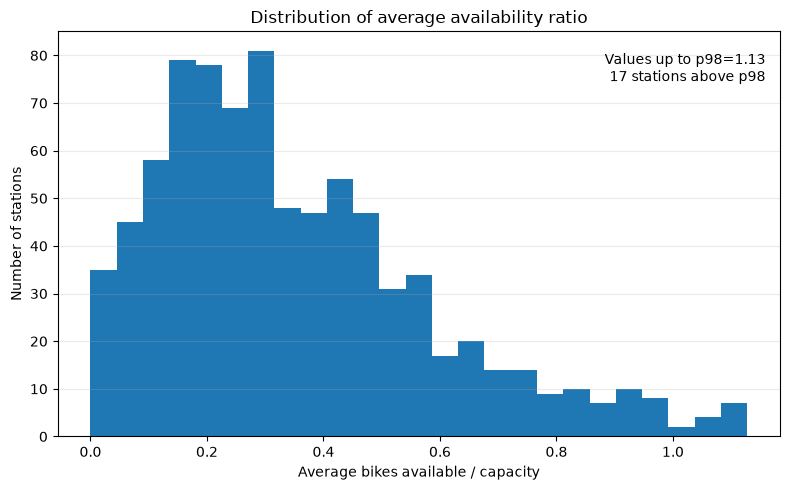

17 stations above p98=1.13; histogram shows values up to p98.


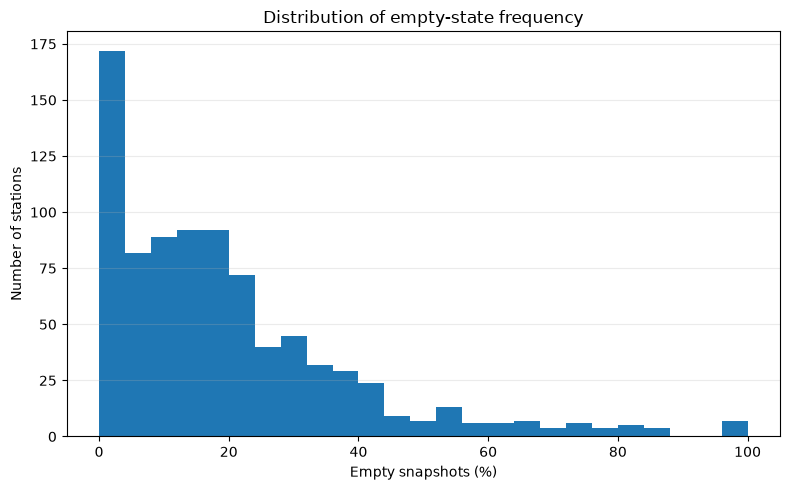

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(station_baseline['avg_bikes_available'].dropna(), bins=25)
ax.set_title('Distribution of station average bike availability')
ax.set_xlabel('Average bikes available')
ax.set_ylabel('Number of stations')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

availability_ratio_values = station_baseline['avg_availability_ratio'].dropna()
availability_ratio_p98 = availability_ratio_values.quantile(0.98)
availability_ratio_central = availability_ratio_values.loc[availability_ratio_values <= availability_ratio_p98]
availability_ratio_above_p98_count = int((availability_ratio_values > availability_ratio_p98).sum())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(availability_ratio_central, bins=25)
ax.set_title('Distribution of average availability ratio')
ax.set_xlabel('Average bikes available / capacity')
ax.set_ylabel('Number of stations')
ax.text(
    0.98,
    0.95,
    f'Values up to p98={availability_ratio_p98:.2f}\n{availability_ratio_above_p98_count} stations above p98',
    transform=ax.transAxes,
    ha='right',
    va='top',
)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()
print(f'{availability_ratio_above_p98_count} stations above p98={availability_ratio_p98:.2f}; histogram shows values up to p98.')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(station_baseline['pct_empty_snapshots'].dropna(), bins=25)
ax.set_title('Distribution of empty-state frequency')
ax.set_xlabel('Empty snapshots (%)')
ax.set_ylabel('Number of stations')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

In [15]:
operational_flags = run_athena_query(f'''
    SELECT flag_name, flag_value, snapshot_count,
           100.0 * snapshot_count / SUM(snapshot_count) OVER (PARTITION BY flag_name) AS pct_snapshots
    FROM (
        SELECT 'is_installed' AS flag_name,
               CASE WHEN is_installed THEN 'True' WHEN NOT is_installed THEN 'False' ELSE 'NULL' END AS flag_value,
               COUNT(*) AS snapshot_count
        FROM {FACT_TABLE} f WHERE {FACT_PERIOD_FILTER} GROUP BY 1, 2
        UNION ALL
        SELECT 'is_renting' AS flag_name,
               CASE WHEN is_renting THEN 'True' WHEN NOT is_renting THEN 'False' ELSE 'NULL' END AS flag_value,
               COUNT(*) AS snapshot_count
        FROM {FACT_TABLE} f WHERE {FACT_PERIOD_FILTER} GROUP BY 1, 2
        UNION ALL
        SELECT 'is_returning' AS flag_name,
               CASE WHEN is_returning THEN 'True' WHEN NOT is_returning THEN 'False' ELSE 'NULL' END AS flag_value,
               COUNT(*) AS snapshot_count
        FROM {FACT_TABLE} f WHERE {FACT_PERIOD_FILTER} GROUP BY 1, 2
    ) flags
    ORDER BY flag_name, flag_value
''')
operational_flags['snapshot_count'] = pd.to_numeric(operational_flags['snapshot_count'])
operational_flags['pct_snapshots'] = pd.to_numeric(operational_flags['pct_snapshots'])
display(operational_flags)

flag_true_share = operational_flags[operational_flags['flag_value'] == 'True'].set_index('flag_name')['pct_snapshots']
if not flag_true_share.empty and (flag_true_share >= 99).all():
    print('The operational flags are almost always True in this analysis period; the table is the primary summary.')

,flag_name,flag_value,snapshot_count,pct_snapshots
0,is_installed,False,6,0.000558
1,is_installed,True,1074562,99.999442
2,is_renting,False,6,0.000558
3,is_renting,True,1074562,99.999442
4,is_returning,False,6,0.000558
5,is_returning,True,1074562,99.999442


The operational flags are almost always True in this analysis period; the table is the primary summary.


## Geospatial EDA

Each point represents one station. Color represents a station-level aggregate over the dynamically discovered analysis period, and point size represents station capacity. These maps do not show user trajectories, exact ride intensity, or a continuous city-wide surface. An empty or full station is an observed station state, not direct evidence of unmet demand.

The source geometry uses `EPSG:4326` from the station latitude and longitude. Only for basemap plotting is the GeoDataFrame converted to `EPSG:3857`; the original coordinates remain unchanged. Extents are calculated from the current valid stations with a dynamic margin, so the maps do not assume a fixed Gdańsk bounding box.

In [16]:
if GEO_IMPORT_ERROR is not None:
    station_geo = None
    station_geo_web = None
    print(f'Geospatial maps skipped: GeoPandas is unavailable ({GEO_IMPORT_ERROR}). Install geopandas before Run All to render maps.')
else:
    geo_source = station_baseline.copy()
    geo_source['latitude'] = pd.to_numeric(geo_source['latitude'], errors='coerce')
    geo_source['longitude'] = pd.to_numeric(geo_source['longitude'], errors='coerce')
    valid_coordinates = (
        geo_source['latitude'].between(-90, 90, inclusive='both')
        & geo_source['longitude'].between(-180, 180, inclusive='both')
    )
    geo_source = geo_source.loc[valid_coordinates].copy()
    station_geo = gpd.GeoDataFrame(
        geo_source,
        geometry=gpd.points_from_xy(geo_source['longitude'], geo_source['latitude']),
        crs='EPSG:4326',
    )
    station_geo_web = station_geo.to_crs(epsg=3857)
    display(pd.DataFrame([{
        'stations in station-level result': len(station_baseline),
        'stations with valid coordinates': len(station_geo),
        'source CRS': station_geo.crs.to_string(),
        'basemap CRS': station_geo_web.crs.to_string(),
    }]))

,stations in station-level result,stations with valid coordinates,source CRS,basemap CRS
0,847,845,EPSG:4326,EPSG:3857


In [17]:
def _set_dynamic_extent(ax, geo_frame, margin_ratio=0.08):
    min_x, min_y, max_x, max_y = geo_frame.total_bounds
    span_x = max(max_x - min_x, 1.0)
    span_y = max(max_y - min_y, 1.0)
    ax.set_xlim(min_x - span_x * margin_ratio, max_x + span_x * margin_ratio)
    ax.set_ylim(min_y - span_y * margin_ratio, max_y + span_y * margin_ratio)

def _add_basemap(ax):
    if ctx is None:
        print(f'Contextily unavailable; rendering the station scatter without a basemap ({CONTEXTILY_IMPORT_ERROR}).')
        return False
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
        return True
    except Exception as exc:
        print(f'Basemap tiles unavailable; using the station scatter fallback. Details: {exc}')
        return False

def plot_station_metric_map(geo_frame, metric, title, colorbar_label, cmap='viridis', percent=False, vmin=None, vmax=None):
    if geo_frame is None or geo_frame.empty:
        print(f'Skipping {title}: no valid station coordinates are available.')
        return
    values = pd.to_numeric(geo_frame[metric], errors='coerce')
    valid_metric = values.notna()
    frame = geo_frame.loc[valid_metric].copy()
    values = values.loc[valid_metric]
    if frame.empty:
        print(f'Skipping {title}: the selected metric has no valid values.')
        return
    capacities = pd.to_numeric(frame['capacity'], errors='coerce').fillna(0).clip(lower=0)
    capacity_scale = capacities / capacities.max() if capacities.max() > 0 else pd.Series(0, index=frame.index)
    point_sizes = 28 + 115 * np.sqrt(capacity_scale)
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(
        frame.geometry.x, frame.geometry.y, c=values, s=point_sizes, cmap=cmap,
        vmin=vmin, vmax=vmax,
        alpha=0.82, edgecolors='white', linewidths=0.35, zorder=3,
    )
    _set_dynamic_extent(ax, frame)
    basemap_added = _add_basemap(ax)
    colorbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
    colorbar.set_label(colorbar_label)
    if percent:
        colorbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value:.0f}%'))
    ax.set_title(title)
    if basemap_added:
        ax.set_axis_off()
    else:
        ax.set_xlabel('Web Mercator X (EPSG:3857)')
        ax.set_ylabel('Web Mercator Y (EPSG:3857)')
    fig.tight_layout()
    plt.show()

Color scale is capped at the 98th percentile for readability. Raw station values are unchanged.

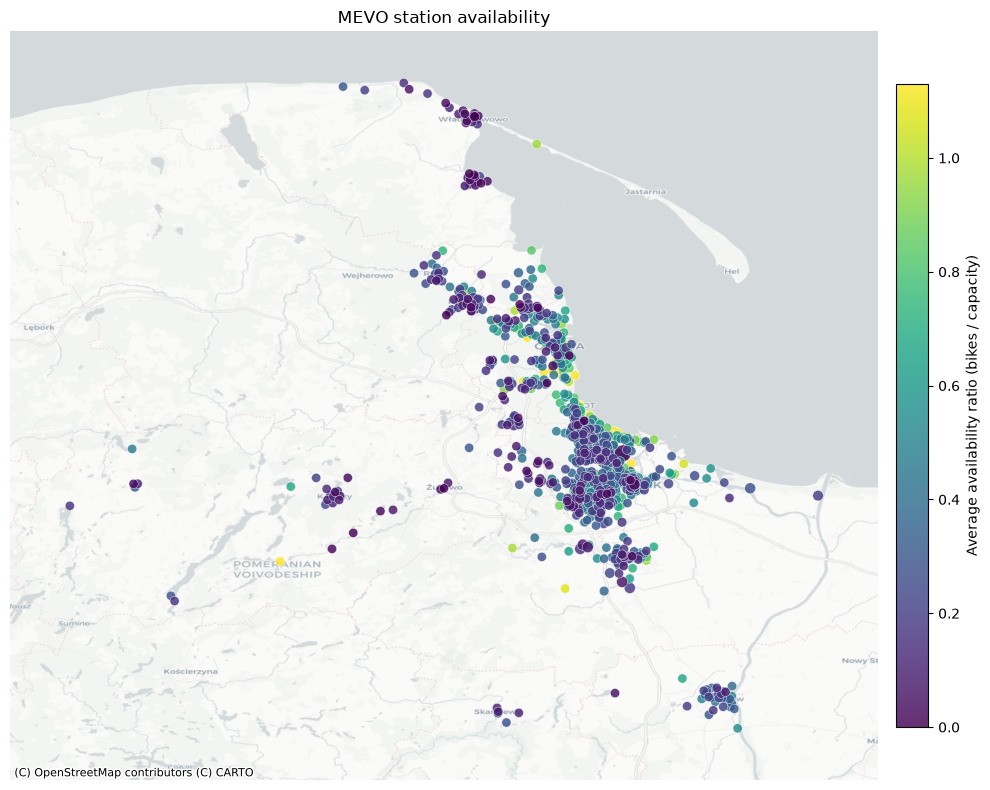

,station_name,avg_availability_ratio,avg_bikes_available,capacity,observation_count
0,SOP008,5.003759,50.037588,10,1277
1,GDA071,2.533203,25.332028,10,1277
2,GDA065,2.200157,22.001566,10,1277
3,GDY077,2.196476,21.964761,10,1277
4,GDY116,1.630227,16.302271,10,1277
5,GDA072,1.547690,15.476899,10,1277
6,GDA027,1.398121,13.981206,10,1277
7,GDY105,1.358496,13.584965,10,1277
41,GDY104,1.353507,9.474550,7,1277
8,GDA068,1.307987,13.079875,10,1277


In [18]:
availability_ratio_p98 = station_baseline['avg_availability_ratio'].quantile(0.98)
availability_ratio_above_p98 = (
    station_baseline.loc[
        station_baseline['avg_availability_ratio'] > availability_ratio_p98,
        ['station_name', 'avg_availability_ratio', 'avg_bikes_available', 'capacity', 'observation_count'],
    ]
    .sort_values('avg_availability_ratio', ascending=False)
    .head(10)
)

plot_station_metric_map(
    station_geo_web,
    metric='avg_availability_ratio',
    title='MEVO station availability',
    colorbar_label='Average availability ratio (bikes / capacity)',
    cmap='viridis',
    vmin=0,
    vmax=availability_ratio_p98,
)
display(availability_ratio_above_p98)

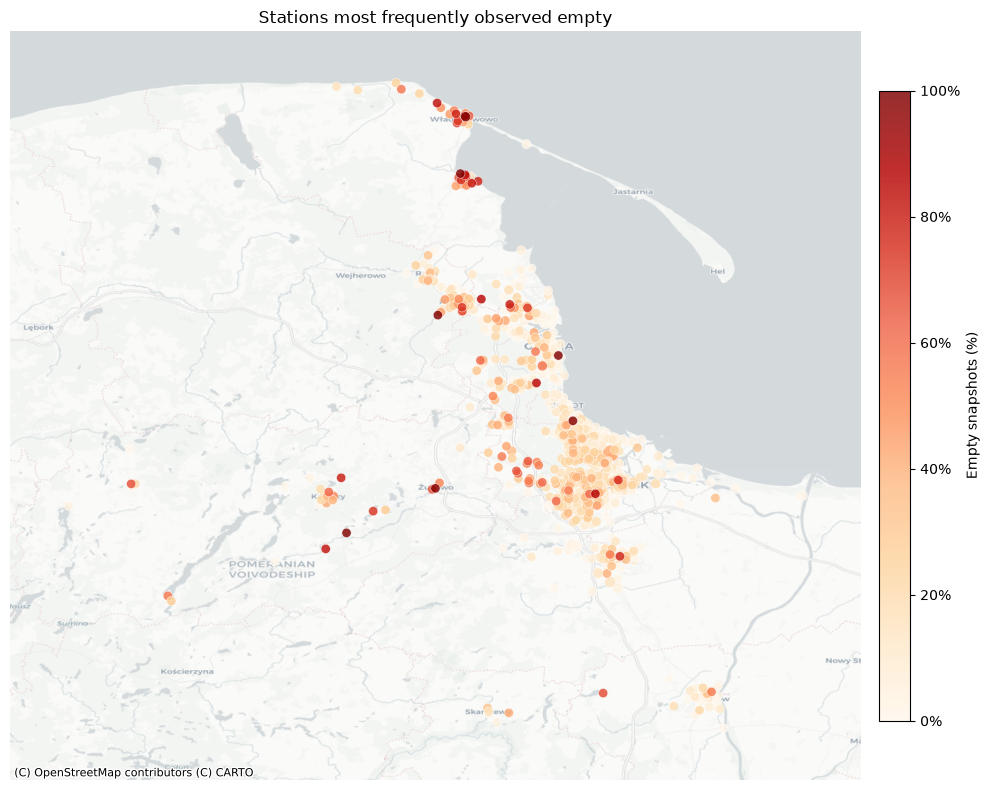

In [19]:
plot_station_metric_map(
    station_geo_web,
    metric='pct_empty_snapshots',
    title='Stations most frequently observed empty',
    colorbar_label='Empty snapshots (%)',
    cmap='OrRd',
    percent=True,
)

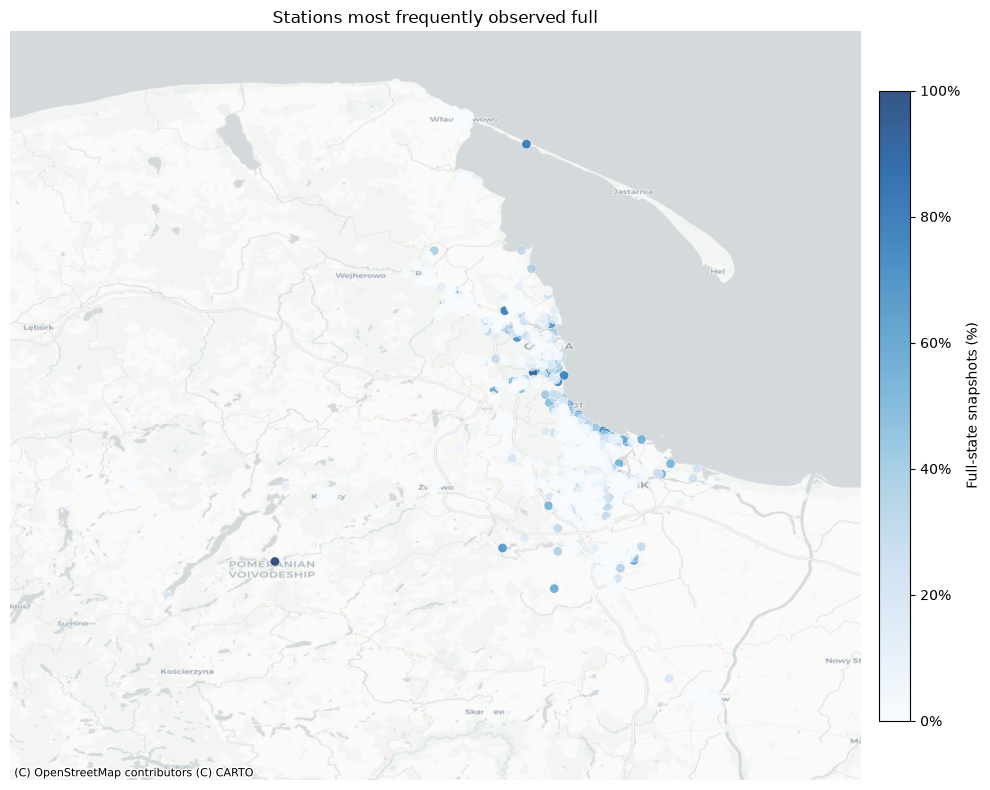

In [20]:
plot_station_metric_map(
    station_geo_web,
    metric='pct_full_snapshots',
    title='Stations most frequently observed full',
    colorbar_label='Full-state snapshots (%)',
    cmap='Blues',
    percent=True,
)

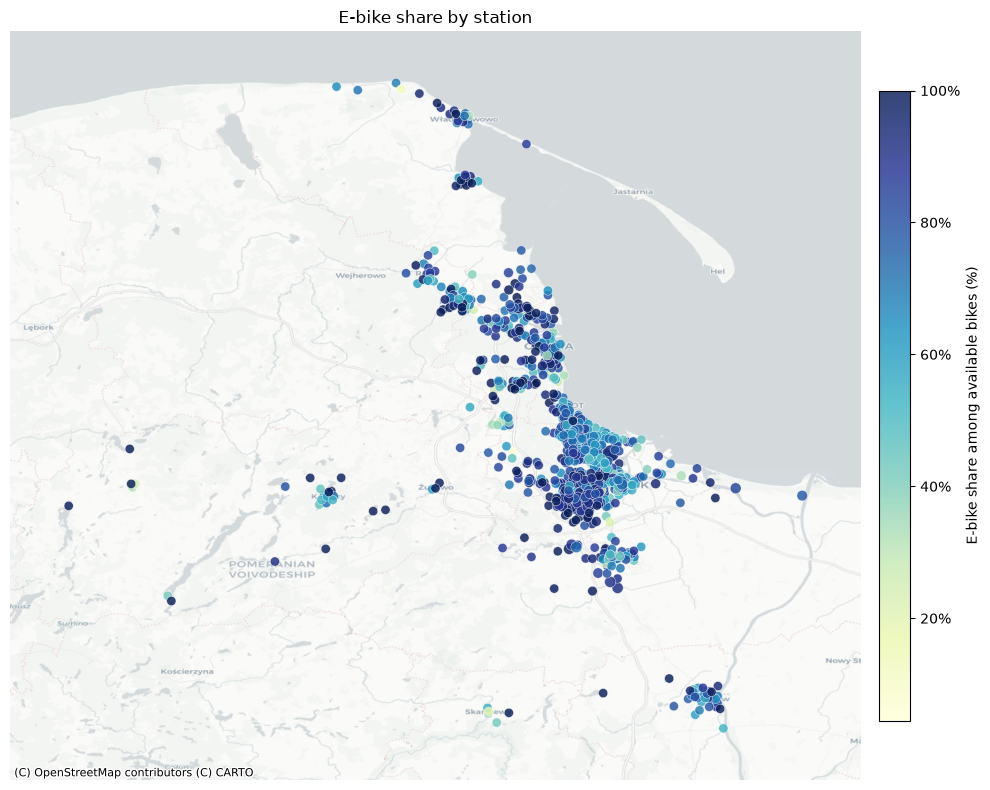

In [21]:
if station_geo_web is not None and station_geo_web['ebike_share'].notna().sum() >= 10:
    plot_station_metric_map(
        station_geo_web,
        metric='ebike_share',
        title='E-bike share by station',
        colorbar_label='E-bike share among available bikes (%)',
        cmap='YlGnBu',
        percent=True,
    )
else:
    print('Optional e-bike share map skipped: fewer than 10 stations have a non-zero available-bike denominator.')

In [22]:
geo_ranking_columns = [
    'station_name', 'avg_availability_ratio', 'pct_empty_snapshots',
    'pct_full_snapshots', 'ebike_share', 'observation_count',
]
geo_ranking = pd.concat([
    station_baseline.nsmallest(5, 'avg_availability_ratio'),
    station_baseline.nlargest(5, 'avg_availability_ratio'),
    station_baseline.nlargest(5, 'pct_empty_snapshots'),
    station_baseline.nlargest(5, 'pct_full_snapshots'),
], ignore_index=True).drop_duplicates(subset=['station_id'])
display(geo_ranking[geo_ranking_columns].head(20))

,station_name,avg_availability_ratio,pct_empty_snapshots,pct_full_snapshots,ebike_share,observation_count
0,KAR016,0.000000,100.000000,0.000000,NaN,1277
1,RUM024,0.000000,100.000000,0.000000,NaN,1277
2,PUC001,0.000000,100.000000,0.000000,NaN,1277
3,Hel Riders,0.000000,100.000000,0.000000,NaN,1277
4,GDY156,0.000267,99.733333,0.000000,100.000000,375
5,SOP008,5.003759,0.000000,83.868442,75.828664,1277
6,GDA071,2.533203,2.270948,70.477682,55.222727,1277
7,GDA065,2.200157,30.540329,38.997651,91.009396,1277
8,GDY077,2.196476,0.000000,93.030540,38.083354,1277
9,GDY116,1.630227,5.716523,74.393109,32.678451,1277


## Key EDA findings

The current CLEANED extract contains 1,074,568 station-status rows, 1,277 snapshots, and 847 stations from 2026-08-12 through 2026-08-20, or approximately nine days. The short history makes these findings preliminary.

- Average system-wide bike availability is highest around 04:00 (approximately 4.53 bikes per reporting station) and lowest around 18:00 (approximately 3.41). These are availability patterns, not direct demand peaks.
- Average bike availability is higher on weekdays (approximately 4.08) than on weekends (approximately 3.57). This comparison is preliminary: Monday, Tuesday, Friday, Saturday, and Sunday each have one observed local calendar date, while Wednesday and Thursday have two.
- E-bikes represent approximately 71.56% of system-wide available bikes in this extract. The hourly profile shows that composition also varies over the day.
- Station-level availability is strongly heterogeneous. SOP008 is an extreme availability hotspot, with an average availability ratio of approximately 5.00 and average available bikes far above its listed capacity. The raw station values are retained; the p98 visualization cap only improves readability, with approximately 17 stations above p98 (p98 ≈ 1.13).
- Empty and nearly-empty states are concentrated unevenly across stations. Several stations are observed empty in every snapshot in this period, while full and nearly-full frequencies also vary substantially by location.
- The static maps make the spatial heterogeneity of availability, empty/full station states, and e-bike share visible across the MEVO operating area.

These are descriptive EDA observations and should not be presented as causal conclusions.

## Hypotheses for Feature Engineering

The following hypotheses can guide the next notebook without being treated as confirmed findings:

- Availability may vary systematically by local hour.
- Weekday and weekend profiles may differ.
- Stations may have different stable baseline availability levels.
- Some locations may reach empty or full states more frequently.
- E-bike and classic-bike composition may vary spatially.
- Geography may be a useful feature for a future model.

**EDA observations are descriptive and are not causal conclusions.** Feature Engineering may later test these hypotheses with lags, rolling features, delta-flow proxies, and an explicitly defined ML target.